In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

In [74]:
# Загрузка данных
df = pd.read_csv('/Users/luiza/Desktop/final_project/sales_ozon_20260721.csv', sep=',')

print(len(df))

2932334


In [75]:
df['purchase_datetime'] = pd.to_datetime(df['purchase_datetime'], errors='coerce')
print(df['purchase_datetime'].dtype)

datetime64[ns]


In [76]:
# Добавляю месяц
df['year_month'] = df['purchase_datetime'].dt.to_period('M')

# Группировка по товару и месяцу
monthly_sales = df.groupby(['product_id', 'year_month'], as_index=False)['total_price'].sum()

In [77]:
# Агрегация по товарам
product_stats = df.groupby('product_id').agg({
    'total_price': 'sum',
    'quantity': 'sum'
}).reset_index()
print(product_stats)

       product_id  total_price  quantity
0               0     50181407      1700
1               1     46918767      1934
2               2     85540081      2684
3               3     43299370      1087
4               4     75410856      1535
...           ...          ...       ...
49995       49995     27912118      1210
49996       49996      8614226      1383
49997       49997     87353856      2308
49998       49998     12999306      1882
49999       49999     46641373      2259

[50000 rows x 3 columns]


In [ ]:
# ABC-анализ по выручке
product_stats = product_stats.sort_values('total_price', ascending=False)
product_stats['cumsum_revenue'] = product_stats['total_price'].cumsum() / product_stats['total_price'].sum()
def abc_class(row):
    if row['cumsum_revenue'] <= 0.8:
        return 'A'
    elif row['cumsum_revenue'] <= 0.95:
        return 'B'
    else:
        return 'C'
product_stats['abc_revenue'] = product_stats.apply(abc_class, axis=1)

In [79]:
# ABC-анализ по количеству
product_stats = product_stats.sort_values('quantity', ascending=False)
product_stats['cumsum_quantity'] = product_stats['quantity'].cumsum() / product_stats['quantity'].sum()
def abc_quantity(row):
    if row['cumsum_quantity'] <= 0.8:
        return 'A'
    elif row['cumsum_quantity'] <= 0.95:
        return 'B'
    else:
        return 'C'
product_stats['abc_quantity'] = product_stats.apply(abc_quantity, axis=1)

In [80]:
# XYZ 
monthly = df.groupby(['product_id', 'year_month'])['quantity'].sum().reset_index()
monthly_stats = monthly.groupby('product_id')['quantity'].agg(['mean', 'std']).reset_index()
monthly_stats['cv'] = monthly_stats['std'] / monthly_stats['mean'].replace(0, np.nan)
monthly_stats['xyz'] = monthly_stats['cv'].apply(lambda x: 'X' if x < 0.1 else ('Y' if x < 0.25 else 'Z'))
monthly_stats['xyz'] = monthly_stats['xyz'].fillna('Z')

In [92]:
# Матрица
matrix = product_stats[['product_id', 'abc_revenue', 'abc_quantity']].merge(
    monthly_stats[['product_id', 'xyz']], on='product_id', how='left'
)
matrix['xyz'] = matrix['xyz'].fillna('Z')
matrix['abc_combined'] = matrix['abc_revenue'] + '_' + matrix['abc_quantity']

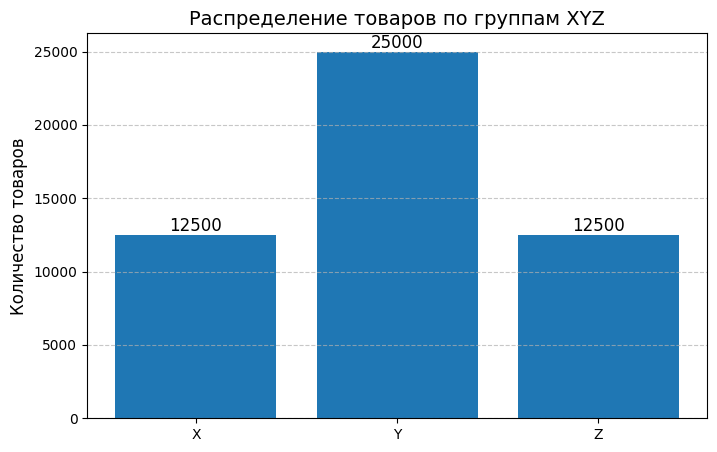

In [94]:
xyz_counts = matrix['xyz'].value_counts().reindex(['X', 'Y', 'Z'], fill_value=0)

# Построение графика
plt.figure(figsize=(8, 5))
bars = plt.bar(xyz_counts.index, xyz_counts.values)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.title('Распределение товаров по группам XYZ', fontsize=14)
plt.ylabel('Количество товаров', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('xyz.png', dpi=300, bbox_inches='tight')
plt.show()



In [85]:
print(f"Минимум: {monthly_stats['cv'].min():.4f}")
print(f"Максимум: {monthly_stats['cv'].max():.4f}")
print(f"Среднее: {monthly_stats['cv'].mean():.4f}")
print(f"Медиана: {monthly_stats['cv'].median():.4f}")
print("\nКвартили и другие перцентили:")
print(monthly_stats['cv'].describe(percentiles=[0.25, 0.75]))

Минимум: 0.2230
Максимум: 1.9512
Среднее: 0.7989
Медиана: 0.7776

Квартили и другие перцентили:
count    50000.000000
mean         0.798877
std          0.205663
min          0.222989
25%          0.652140
50%          0.777589
75%          0.924641
max          1.951216
Name: cv, dtype: float64


In [88]:
# Новые пороги для XYZ
x = monthly_stats['cv'].quantile(0.25)   
y = monthly_stats['cv'].quantile(0.75)


# Назначение групп
def assign_xyz(cv):
    if pd.isna(cv):
        return 'Z'
    elif cv <= x:
        return 'X'
    elif cv <= y:
        return 'Y'
    else:
        return 'Z'

monthly_stats['xyz'] = monthly_stats['cv'].apply(assign_xyz)

print("\nРаспределение по группам:")
print(monthly_stats['xyz'].value_counts().sort_index())


Распределение по группам:
xyz
X    12500
Y    25000
Z    12500
Name: count, dtype: int64


In [83]:
print("Распределение товаров по категориям (ABC (выручка) × ABC (количество) × XYZ):")
print(matrix.groupby(['abc_revenue', 'abc_quantity', 'xyz']).size().unstack(fill_value=0))

Распределение товаров по категориям (ABC (выручка) × ABC (количество) × XYZ):
xyz                       Y      Z
abc_revenue abc_quantity          
A           A             1  21452
            B             2   4200
            C             0   1201
B           A             0   7538
            B             1   2660
            C             1   1382
C           A             1   7567
            B             0   2607
            C             0   1387


In [ ]:
# Количество товаров по группам ABC (выручка) и XYZ
pivot_count = pd.crosstab(
    matrix['abc_combined'] ,
    matrix['xyz'],
    margins=True,
    margins_name='Всего'
)
print(pivot_count)

xyz               X      Y      Z  Всего
abc_combined                            
A_A            4720  10761   5972  21453
A_B            1331   2089    782   4202
A_C             399    585    217   1201
B_A            1744   3804   1990   7538
B_B             810   1336    515   2661
B_C             450    699    234   1383
C_A            1757   3744   2067   7568
C_B             861   1256    490   2607
C_C             428    726    233   1387
Всего         12500  25000  12500  50000


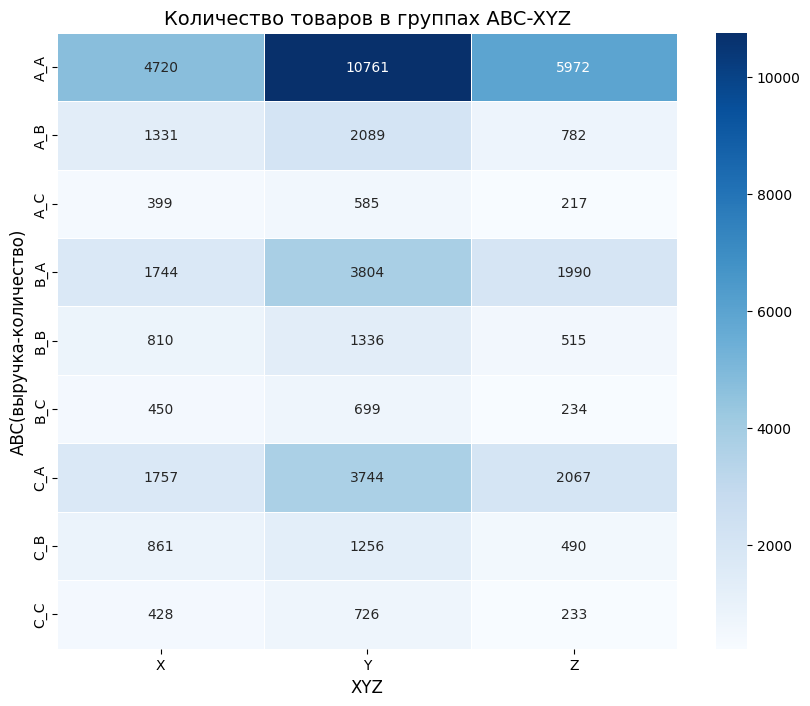

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Убираем итоговую строку и столбец, чтобы не искажать масштаб
heat_data = pivot_count.loc[['A_A','A_B','A_C','B_A','B_B','B_C','C_A','C_B','C_C'], ['X','Y','Z']]

plt.figure(figsize=(10, 8))
sns.heatmap(heat_data, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Количество товаров в группах ABC-XYZ', fontsize=14)
plt.xlabel('XYZ', fontsize=12)
plt.ylabel('ABC(выручка-количество)', fontsize=12)
plt.savefig('abc-xyz.png', dpi=300, bbox_inches='tight')
plt.show()